# Unemployment in the Canary Islands (2000–2026)

**Dataset**: Indicadores de prestaciones por desempleo. Canarias y provincias por periodos

**Source**: [ISTAC](https://datos.canarias.es) — Instituto Canario de Estadistica

**Question**: How has unemployment evolved across the Canary Islands? What share of jobseekers receive benefits?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")
OUTPUT_DIR = Path("output/figures")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH = "data/raw/1.21.csv"
df = pd.read_csv(CSV_PATH)
print(f"Rows: {len(df)} | Columns: {list(df.columns)}")
df.head(2)

Rows: 1872 | Columns: ['TERRITORIO#es', 'TERRITORIO_CODE', 'TIME_PERIOD#es', 'TIME_PERIOD_CODE', 'MEDIDAS#es', 'MEDIDAS_CODE', 'OBS_VALUE', 'ESTADO_OBSERVACION#es', 'CONFIDENCIALIDAD_OBSERVACION#es', 'NOTAS_OBSERVACION#es']


,TERRITORIO#es,TERRITORIO_CODE,TIME_PERIOD#es,TIME_PERIOD_CODE,MEDIDAS#es,MEDIDAS_CODE,OBS_VALUE,ESTADO_OBSERVACION#es,CONFIDENCIALIDAD_OBSERVACION#es,NOTAS_OBSERVACION#es
0,Canarias,ES70,08/2011,2011-M08,Tasa de cobertura de la prestación de desempleo,TASA_COBERTURA_PRESTACION_DESEMPLEO,69.4,NaN,NaN,NaN
1,Canarias,ES70,08/2011,2011-M08,Personas beneficiarias,PERSONAS_BENEFICIARIAS,167141.0,NaN,NaN,NaN


In [2]:
def parse_period(s):
    s = str(s)
    if "-M" in s:
        parts = s.split("-M")
        return pd.Timestamp(parts[0] + "-" + parts[1].zfill(2) + "-01")
    else:
        return pd.Timestamp(s + "-06-30")

df["date"] = df["TIME_PERIOD_CODE"].apply(parse_period)
df = df.sort_values(["date", "TERRITORIO#es"])
df = df.rename(columns={
    "TERRITORIO#es": "territory",
    "MEDIDAS#es": "measure",
    "MEDIDAS_CODE": "measure_code",
    "OBS_VALUE": "value"
})

print("Date range:", df["date"].min().strftime("%Y-%m"), "->", df["date"].max().strftime("%Y-%m"))
print("Territories:", list(df["territory"].unique()))
print("Measures:", list(df["measure"].unique()))

Date range: 2000-06 -> 2026-02
Territories: ['Canarias', 'Las Palmas', 'Santa Cruz de Tenerife']
Measures: ['Tasa de cobertura de la prestación de desempleo', 'Personas beneficiarias', 'Paro resgistrado con experiencia laboral']


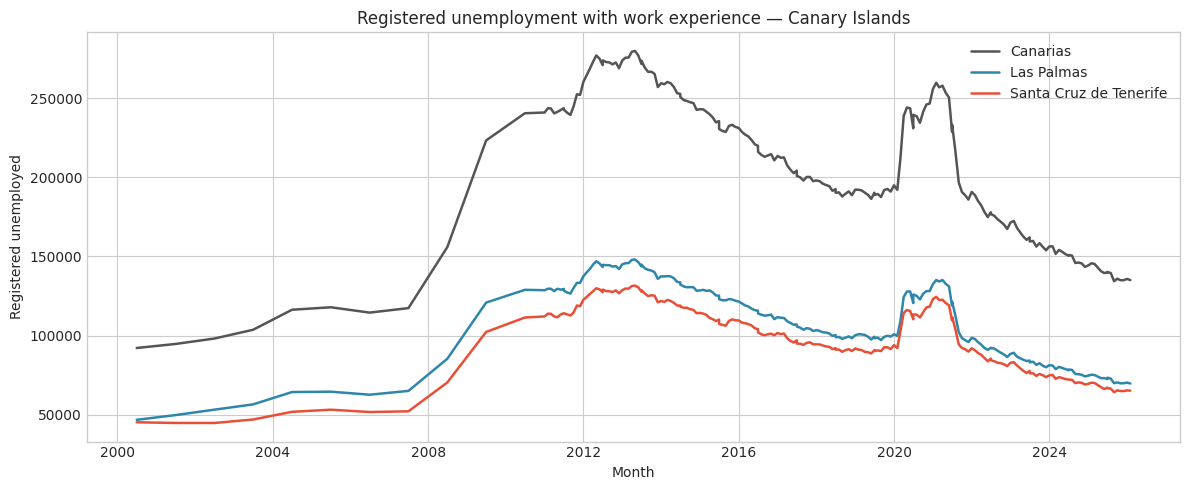

Saved: output/figures/unemployment_total_trend.png


In [3]:
# 1. Registered unemployment — Canarias vs provinces
paro = df[df["measure_code"] == "PARO_REGISTRADO_EXPERIENCIA_LABORAL"].copy()

fig, ax = plt.subplots(figsize=(12, 5))
colors = {"Canarias": "#555555", "Las Palmas": "#2E86AB", "Santa Cruz de Tenerife": "#E94F37"}
for t, color in colors.items():
    d = paro[paro["territory"] == t].sort_values("date")
    ax.plot(d["date"], d["value"], label=t, color=color, linewidth=1.8)
ax.set_xlabel("Month")
ax.set_ylabel("Registered unemployed")
ax.set_title("Registered unemployment with work experience — Canary Islands")
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "unemployment_total_trend.png", dpi=150)
plt.show()
print("Saved: output/figures/unemployment_total_trend.png")

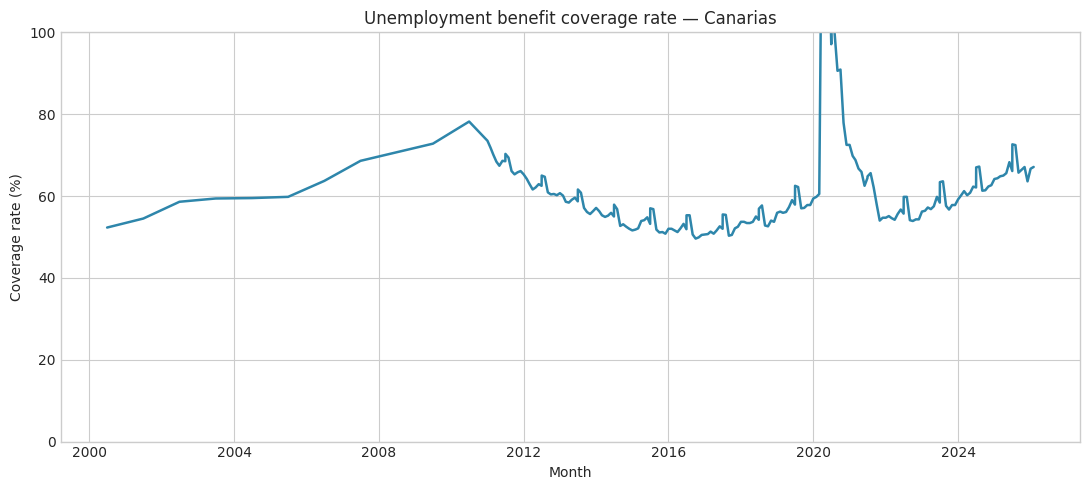

Saved: output/figures/unemployment_coverage_rate.png


In [4]:
# 2. Benefit coverage rate — Canarias
tasa = df[df["measure_code"] == "TASA_COBERTURA_PRESTACION_DESEMPLEO"].copy()
can_tasa = tasa[tasa["territory"] == "Canarias"].sort_values("date")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(can_tasa["date"], can_tasa["value"], color="#2E86AB", linewidth=1.8)
ax.set_xlabel("Month")
ax.set_ylabel("Coverage rate (%)")
ax.set_title("Unemployment benefit coverage rate — Canarias")
ax.set_ylim(0, 100)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "unemployment_coverage_rate.png", dpi=150)
plt.show()
print("Saved: output/figures/unemployment_coverage_rate.png")

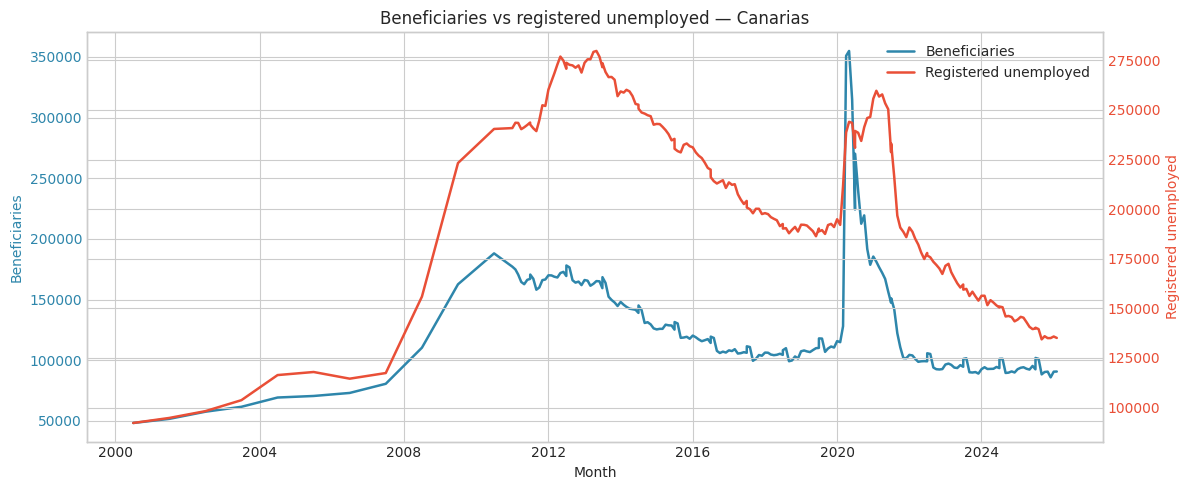

Saved: output/figures/unemployment_beneficiaries_vs_registered.png


In [5]:
# 3. Beneficiaries vs registered unemployed — Canarias (dual axis)
can = df[df["territory"] == "Canarias"].copy()

fig, ax1 = plt.subplots(figsize=(12, 5))

benef = can[can["measure_code"] == "PERSONAS_BENEFICIARIAS"].sort_values("date")
paro_can = can[can["measure_code"] == "PARO_REGISTRADO_EXPERIENCIA_LABORAL"].sort_values("date")

ax1.plot(benef["date"], benef["value"], label="Beneficiaries", color="#2E86AB", linewidth=1.8)
ax1.set_ylabel("Beneficiaries", color="#2E86AB")
ax1.tick_params(axis="y", labelcolor="#2E86AB")

ax2 = ax1.twinx()
ax2.plot(paro_can["date"], paro_can["value"], label="Registered unemployed", color="#E94F37", linewidth=1.8)
ax2.set_ylabel("Registered unemployed", color="#E94F37")
ax2.tick_params(axis="y", labelcolor="#E94F37")

ax1.set_xlabel("Month")
ax1.set_title("Beneficiaries vs registered unemployed — Canarias")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "unemployment_beneficiaries_vs_registered.png", dpi=150)
plt.show()
print("Saved: output/figures/unemployment_beneficiaries_vs_registered.png")

In [6]:
# 4. Key numbers — latest month
latest_date = df["date"].max()
print("Latest data:", latest_date.strftime("%Y-%m"))
print()
for t in ["Canarias", "Las Palmas", "Santa Cruz de Tenerife"]:
    row = df[(df["date"] == latest_date) & (df["territory"] == t)]
    ben = row[row["measure_code"] == "PERSONAS_BENEFICIARIAS"]["value"].values[0]
    par = row[row["measure_code"] == "PARO_REGISTRADO_EXPERIENCIA_LABORAL"]["value"].values[0]
    tas = row[row["measure_code"] == "TASA_COBERTURA_PRESTACION_DESEMPLEO"]["value"].values[0]
    print(f"{t}: {ben:,.0f} beneficiaries | {par:,.0f} registered | coverage {tas:.1f}%")

Latest data: 2026-02

Canarias: 90,670 beneficiaries | 135,114 registered | coverage 67.1%
Las Palmas: 47,058 beneficiaries | 69,836 registered | coverage 67.4%
Santa Cruz de Tenerife: 43,612 beneficiaries | 65,278 registered | coverage 66.8%
